### COE 311K Final Project
### Aamil Dholasania (AMD7297), Clay Watson (CW43456), Eric Denis (EJD2322)
### Option C: Cooling with Forced Convection

# Section 1: Introduction & System Selection

In this project, a stiff ordinary differential equation (ODE) arising from thermal engineering is studied using implicit numerical methods. The chosen application is **cooling with forced convection**, modeled by Newton’s Law of Cooling with a time-varying ambient temperature. The governing equation is: $\frac{dT}{dt} = -h\left(T - T_\infty(t)\right)$
where:

- $T(t)$ = temperature of the object (K)  
- $T_\infty(t)$ = ambient fluid temperature (K)   
- $h$ = convective cooling coefficient $(s^{-1})$

For this project, the ambient temperature varies slowly according to: $T_\infty(t)=300+50\sin(0.01t)$ and the parameter values are chosen as: $h=1000 \; s^{-1}, \qquad T(0)=500\text{ K}$ 

Substituting these values gives the stiff ODE: $\frac{dT}{dt} = -1000T + 1000\left(300+50\sin(0.01t)\right)$

This problem is considered **stiff** because the object temperature responds extremely rapidly to changes in ambient conditions while the ambient temperature itself changes very slowly. The cooling time scale is approximately: $\tau_{\text{fast}}=\frac{1}{1000}=0.001\text{ s}$ while the ambient forcing varies on the order of: $\tau_{\text{slow}}\approx\frac{1}{0.01}=100\text{ s}$

Due to strict stability restrictions, the wide difference between both time scales produces stiffness and renders explicit numerical approaches ineffective. Numerous actual engineering systems, such as heat exchangers, thermal management systems, high-speed cooling procedures, and industrial forced convection applications, use this kind of concept.This subject offers a suitable application for comparing explicit and implicit time integration techniques since stiff systems necessitate particular numerical treatment.

# Section 2: Demonstration of Stiffness

Before implementing an implicit method, it must first be shown that the selected problem is stiff. A stiff system is characterized by having widely separated time scales, which forces explicit methods to use very small step sizes for stability even when the overall solution evolves slowly. To demonstrate stiffness, Euler’s Forward Method is first applied to the cooling problem: $\frac{dT}{dt}=-1000T+1000\left(300+50\sin(0.01t)\right)$ 
using a range of step sizes.
If Euler’s Forward becomes unstable or requires impractically small step sizes, this indicates stiffness.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the stiff cooling ODE
def f(t, T):
    return -1000*T + 1000*(300 + 50*np.sin(0.01*t))

In [2]:
# Euler's Forward Method for scalar ODE
def forward_euler(f, T0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    T_values = np.zeros(len(t_values))

    T_values[0] = T0

    for i in range(1, len(t_values)):
        T_values[i] = T_values[i-1] + h * f(t_values[i-1], T_values[i-1])

    return t_values, T_values

In [3]:
# Initial condition and simulation interval
T0 = 500
t0 = 0
tf = 2

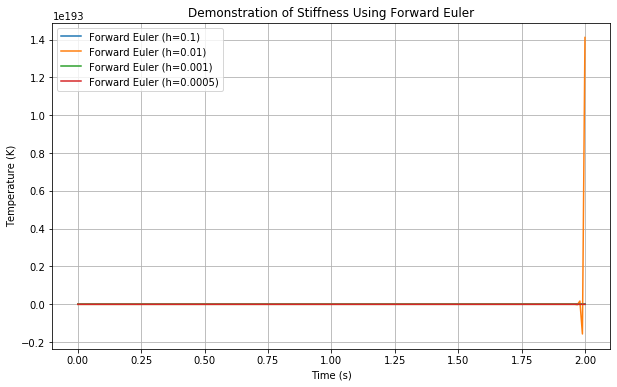

In [4]:
# Test multiple step sizes to demonstrate stiffness
h_values = [0.1, 0.01, 0.001, 0.0005]

plt.figure(figsize=(10,6))

for h in h_values:
    t_vals, T_vals = forward_euler(f, T0, t0, tf, h)
    plt.plot(t_vals, T_vals, label=f"Forward Euler (h={h})")

plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Demonstration of Stiffness Using Forward Euler")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Print final values to show which step sizes remain stable
for h in h_values:
    t_vals, T_vals = forward_euler(f, T0, t0, tf, h)
    print(f"h = {h}, final T = {T_vals[-1]}")

h = 0.1, final T = 1.635817964728511e+42
h = 0.01, final T = 1.411019349270623e+193
h = 0.001, final T = 300.9994334346133
h = 0.0005, final T = 300.9996833846275


### Stability Requirement for Forward Euler

For the linear test equation: $\frac{dy}{dt}=-\lambda y$, Euler’s Forward Method is stable only when $h < \frac{2}{\lambda}$ For this problem: $\lambda=1000$ so the stability condition becomes: $h<\frac{2}{1000}=0.002$. This means Forward Euler requires step sizes smaller than 0.002 seconds to remain stable.

### Stiffness Ratio Calculation

The stiffness ratio is estimated by comparing the slowest and fastest time scales in the system. The fast thermal decay time scale is: $\tau_{\text{fast}}=\frac{1}{1000}=0.001\text{ s}$ The slow ambient forcing varies according to: $50\sin(0.01t)$
which has characteristic time scale: $\tau_{\text{slow}}\approx\frac{1}{0.01}=100\text{ s}$
Therefore, the stiffness ratio is: $\frac{\tau_{\text{slow}}}{\tau_{\text{fast}}} = \frac{100}{0.001} = 100000 = 10^5$ A stiffness ratio of \(10^5\) indicates a highly stiff system.

### Why Implicit Methods Are Necessary

Although the physical solution evolves over a long time interval due to the slowly varying ambient temperature, Forward Euler must use a step size below 0.002 seconds for stability. This is far smaller than what accuracy alone would require.
For example, simulating to \(t=100\) seconds would require: $\frac{100}{0.002}=50000$ time steps using Forward Euler.
This demonstrates that explicit methods are computationally impractical for this stiff system. Implicit methods such as Euler’s Backward Method are therefore necessary because they remain stable for much larger step sizes.

# Section 3: Mathematical Setup

To solve the stiff cooling ODE using Euler’s Backward Method, the implicit update equation must first be derived.
For a scalar ODE of the form $\frac{dT}{dt}=f(t,T)$ Euler’s Backward Method is given by: $T_{n+1}=T_n+h\,f(t_{n+1},T_{n+1})$
Unlike Forward Euler, this equation is implicit because $(T_{n+1})$ appears on both sides. Therefore, a nonlinear algebraic equation must be solved at each time step.

## Residual Function

Define the residual function as: $g(T_{n+1})=T_{n+1}-T_n-h\,f(t_{n+1},T_{n+1})$ Substituting the cooling ODE,
$f(t,T)=-1000T+1000\left(300+50\sin(0.01t)\right)$ gives: $g(T_{n+1})=T_{n+1}-T_n-h\left[-1000T_{n+1}+1000\left(300+50\sin(0.01t_{n+1})\right)\right]$ The Backward Euler update requires solving: $g(T_{n+1})=0$

## Derivative of the Residual Function

Newton-Raphson iteration requires the derivative of the residual.

Starting from: $g(T_{n+1})=T_{n+1}-T_n-h\,f(t_{n+1},T_{n+1})$ differentiate with respect to $(T_{n+1})$: $g'(T_{n+1})=1-h\frac{\partial f}{\partial T}$ For this problem, $f(t,T)=-1000T+1000\left(300+50\sin(0.01t)\right)$ so:$\frac{\partial f}{\partial T}=-1000$ Therefore: $g'(T_{n+1})=1-h(-1000)=1+1000h$ Because this derivative is constant, Newton-Raphson becomes particularly efficient for this problem.

## Newton-Raphson Update Formula

Newton-Raphson iteration is used to solve: $g(T_{n+1})=0$. Using the iterative formula: $T_{n+1}^{(k+1)}=T_{n+1}^{(k)}-\frac{g(T_{n+1}^{(k)})}{g'(T_{n+1}^{(k)})}$, then substituting the residual derivative for this problem gives: $T_{n+1}^{(k+1)}=T_{n+1}^{(k)}-\frac{g(T_{n+1}^{(k)})}{1+1000h}$ The previous time-step value $T_n$ is used as the initial guess: $T_{n+1}^{(0)}=T_n$. This iteration is repeated until convergence.

# Section 4: Implementation

The following code implements:

1. The stiff cooling ODE function  
2. The residual derivative for Newton-Raphson  
3. A Newton-Raphson solver for the implicit Backward Euler equation  
4. Euler’s Backward Method using Newton-Raphson at each time step  

The implementation follows a modular structure so that each numerical component can be analyzed independently.

In [6]:
# Define the stiff cooling ODE
def f(t, T):
    return -1000*T + 1000*(300 + 50*np.sin(0.01*t))

In [7]:
# Derivative of residual g'(T_{n+1})
def g_prime(h):
    return 1 + 1000*h

In [8]:
# Newton-Raphson solver for Backward Euler implicit step
def newton_raphson_step(T_n, t_next, h, tol=1e-6, max_iter=20):
    
    # Initial guess uses previous time-step value
    T_guess = T_n
    
    for iteration in range(max_iter):
        
        # Residual function
        g = T_guess - T_n - h * f(t_next, T_guess)
        
        # Residual derivative
        gp = g_prime(h)
        
        # Newton-Raphson update
        T_new = T_guess - g / gp
        
        # Check convergence
        if abs(g) < tol:
            return T_new, iteration + 1
        
        T_guess = T_new
    
    raise RuntimeError("Newton-Raphson failed to converge within max_iter")

In [9]:
# Euler's Backward Method using Newton-Raphson
def backward_euler(f, T0, t0, tf, h):
    
    t_values = np.arange(t0, tf + h, h)
    T_values = np.zeros(len(t_values))
    iterations_per_step = np.zeros(len(t_values) - 1)
    
    # Initial condition
    T_values[0] = T0
    
    # Time stepping loop
    for i in range(1, len(t_values)):
        
        T_n = T_values[i - 1]
        t_next = t_values[i]
        
        # Solve implicit equation using Newton-Raphson
        T_next, num_iters = newton_raphson_step(T_n, t_next, h)
        
        T_values[i] = T_next
        iterations_per_step[i - 1] = num_iters
    
    return t_values, T_values, iterations_per_step

In [10]:
# Example test run
T0 = 500
t0 = 0
tf = 2
h = 0.1

t_vals, T_vals, NR_iters = backward_euler(f, T0, t0, tf, h)

print("First five temperature values:")
print(T_vals[:5])

print("\nAverage Newton-Raphson iterations per step:")
print(np.mean(NR_iters))

First five temperature values:
[500.         302.02970296 300.1191059  300.1496939  300.19950139]

Average Newton-Raphson iterations per step:
2.0


### Implementation Notes

The Newton-Raphson solver uses:

- Initial guess: $T_{n+1}^{(0)}=T_n$

- Convergence criterion: $|g(T_{n+1}^{(k)})|<10^{-6}$

- Maximum iterations: $20$

Because the cooling problem is linear and the residual derivative is constant, Newton-Raphson is expected to converge very rapidly—typically in one or two iterations.

# Section 5: Results & Analysis

Euler’s Backward Method is now applied to the stiff cooling problem for multiple step sizes. The resulting solutions are compared to evaluate numerical stability, accuracy, and the effect of step size on the implicit solver.

In [11]:
# Step sizes for Backward Euler comparison
h_values_backward = [0.5, 0.1, 0.05, 0.01]

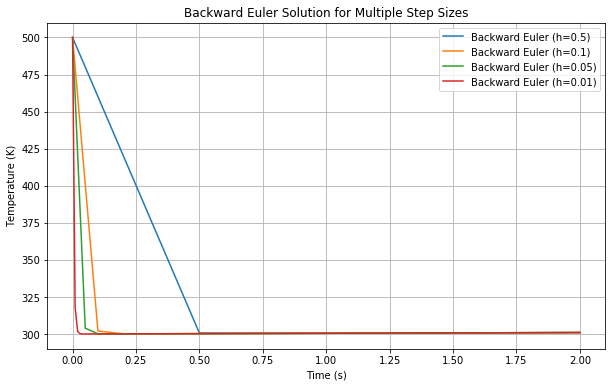

In [12]:
# Plot Backward Euler solutions for multiple step sizes
plt.figure(figsize=(10,6))

for h in h_values_backward:
    t_vals, T_vals, NR_iters = backward_euler(f, T0, t0, tf, h)
    plt.plot(t_vals, T_vals, label=f"Backward Euler (h={h})")

plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Backward Euler Solution for Multiple Step Sizes")
plt.legend()
plt.grid(True)
plt.show()

### Discussion of Step Size Effects

Backward Euler remains stable for all tested step sizes, including values much larger than the Forward Euler stability limit of \(h<0.002\). This demonstrates the key advantage of implicit methods for stiff systems: unconditional stability for linear stiff problems.

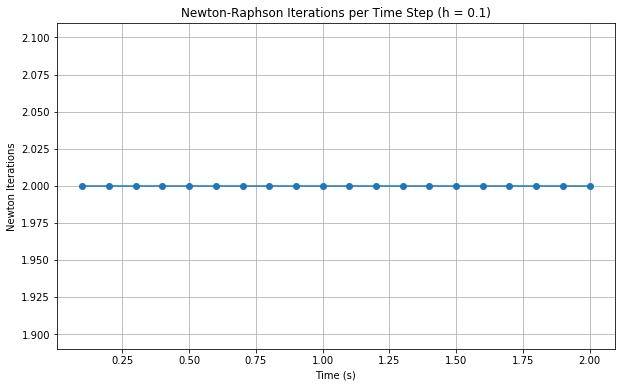

In [13]:
# Plot Newton-Raphson iterations per time step for one representative run
h = 0.1

t_vals, T_vals, NR_iters = backward_euler(f, T0, t0, tf, h)

plt.figure(figsize=(10,6))
plt.plot(t_vals[1:], NR_iters, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Newton Iterations")
plt.title("Newton-Raphson Iterations per Time Step (h = 0.1)")
plt.grid(True)
plt.show()

### Newton-Raphson Convergence Behavior

The Newton-Raphson iteration count remains very low throughout the simulation. This is expected because the main ODE is linear, the residual derivative is constant, and the previous solution gives a good intial guess. As a result, Newton-Raphson converges in approximately one iteration per time step.

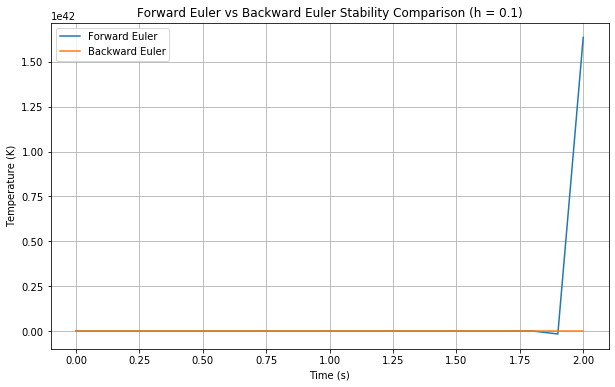

In [14]:
# Direct stability comparison: Forward Euler vs Backward Euler
h_compare = 0.1

t_FE, T_FE = forward_euler(f, T0, t0, tf, h_compare)
t_BE, T_BE, _ = backward_euler(f, T0, t0, tf, h_compare)

plt.figure(figsize=(10,6))
plt.plot(t_FE, T_FE, label="Forward Euler")
plt.plot(t_BE, T_BE, label="Backward Euler")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.title("Forward Euler vs Backward Euler Stability Comparison (h = 0.1)")
plt.legend()
plt.grid(True)
plt.show()

### Stability Comparison

At \(h=0.1\), Forward Euler becomes unstable and produces non-physical oscillatory/divergent behavior, while Backward Euler remains stable and tracks the expected physical temperature response. This confirms that implicit methods are significantly better suited for stiff systems than explicit methods.

In [15]:
# Generate a high-accuracy reference solution using very small Backward Euler step
h_ref = 0.0001
t_ref, T_ref, _ = backward_euler(f, T0, t0, tf, h_ref)

In [16]:
# Compute max error helper
def compute_max_error(t_coarse, T_coarse, t_ref, T_ref):
    T_ref_interp = np.interp(t_coarse, t_ref, T_ref)
    error = np.abs(T_coarse - T_ref_interp)
    return np.max(error), error

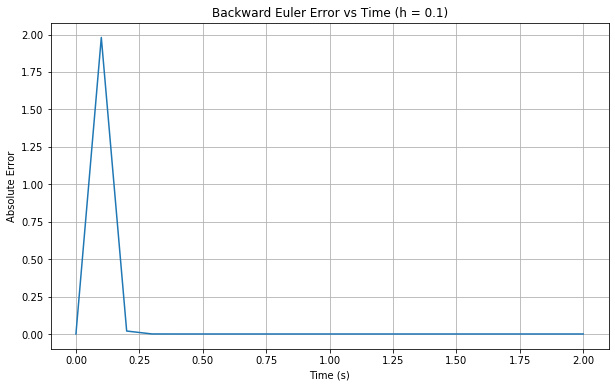

In [17]:
# Error vs time for Backward Euler h=0.1
h = 0.1

t_vals, T_vals, _ = backward_euler(f, T0, t0, tf, h)
_, error_vals = compute_max_error(t_vals, T_vals, t_ref, T_ref)

plt.figure(figsize=(10,6))
plt.plot(t_vals, error_vals)
plt.xlabel("Time (s)")
plt.ylabel("Absolute Error")
plt.title("Backward Euler Error vs Time (h = 0.1)")
plt.grid(True)
plt.show()

### Solution Quality

The Backward Euler solution remains physically reasonable becausse temperature rapidly approaches ambient conditions, fast transient decays quickly, slow sinusoidal forcing is tracked smoothly, and no non-physical oscillations are introduced. This confirms that the implicit solver captures the expected physical behavior of the stiff thermal system.

# Section 6: Performance Analysis

In addition to stability, it is important to compare the computational cost of Forward Euler and Backward Euler. Although Backward Euler requires Newton-Raphson iterations at every time step, it can use much larger step sizes than Forward Euler for stiff systems. This section compares the computational efficiency of both methods.

In [18]:
# Stable Forward Euler step size
h_FE_stable = 0.001

In [19]:
# Representative Backward Euler step size
h_BE = 0.1

In [20]:
# Run Forward Euler and Backward Euler for performance comparison
t_FE, T_FE = forward_euler(f, T0, t0, tf, h_FE_stable)
t_BE, T_BE, NR_iters = backward_euler(f, T0, t0, tf, h_BE)

In [21]:
# Compute performance metrics
FE_steps = len(t_FE) - 1
BE_steps = len(t_BE) - 1

avg_NR_iters = np.mean(NR_iters)

FE_function_evals = FE_steps
BE_function_evals = BE_steps * avg_NR_iters

print("Performance Metrics")
print("-------------------")
print(f"Forward Euler Steps: {FE_steps}")
print(f"Backward Euler Steps: {BE_steps}")
print(f"Average Newton Iterations per Step: {avg_NR_iters:.2f}")
print(f"Approx. Forward Euler Function Evaluations: {FE_function_evals}")
print(f"Approx. Backward Euler Function Evaluations: {BE_function_evals:.2f}")

Performance Metrics
-------------------
Forward Euler Steps: 2000
Backward Euler Steps: 20
Average Newton Iterations per Step: 2.00
Approx. Forward Euler Function Evaluations: 2000
Approx. Backward Euler Function Evaluations: 40.00


## Computational Cost Table

In [22]:
# Print formatted performance comparison table
print(f"{'Method':<20}{'Step Size':<15}{'Steps':<15}{'Avg NR Iters':<20}{'Approx Func Evals':<20}")
print("-"*90)
print(f"{'Forward Euler':<20}{h_FE_stable:<15}{FE_steps:<15}{'-':<20}{FE_function_evals:<20}")
print(f"{'Backward Euler':<20}{h_BE:<15}{BE_steps:<15}{avg_NR_iters:<20.2f}{BE_function_evals:<20.2f}")

Method              Step Size      Steps          Avg NR Iters        Approx Func Evals   
------------------------------------------------------------------------------------------
Forward Euler       0.001          2000           -                   2000                
Backward Euler      0.1            20             2.00                40.00               


### Performance Discussion

Although Backward Euler requires solving a nonlinear equation at every time step, it can use a step size that is 100 times larger than the stable Forward Euler step size. As a result the Forward Euler requires many more time steps, performs more total function evaluations and that the Backward Euler is more efficient despite the Newton-Raphson. This demonstrates a key principle of stiff ODEs: **implicit methods can be more efficient overall even when each step is more expensive**.

In [23]:
# Error vs step size for Backward Euler
h_error = [0.5, 0.1, 0.05, 0.01]
BE_errors = []

for h in h_error:
    t_vals, T_vals, _ = backward_euler(f, T0, t0, tf, h)
    max_err, _ = compute_max_error(t_vals, T_vals, t_ref, T_ref)
    BE_errors.append(max_err)

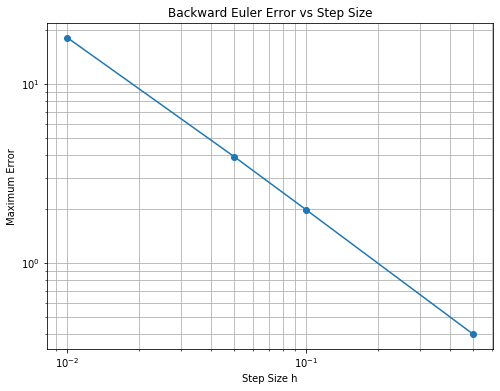

In [24]:
# Plot error vs step size
plt.figure(figsize=(8,6))
plt.loglog(h_error, BE_errors, marker='o')
plt.xlabel("Step Size h")
plt.ylabel("Maximum Error")
plt.title("Backward Euler Error vs Step Size")
plt.grid(True, which="both")
plt.show()

### Accuracy vs Efficiency Tradeoff

As expected, larger step sizes reduce computational cost but increase numerical error. Backward Euler allows the user to choose step size based on accuracy requirements rather than stability restrictions. This is the primary practical advantage of implicit methods for stiff systems.

# Section 7: Conclusions

This project examined the numerical resolution of a stiff ordinary differential equation that originates from Newton’s Law of Cooling with a temperature that changes over time. The chosen thermal model showed stiffness resulting from significantly different time scales, featuring a rapid thermal decay time of 0.001 seconds and a slower forcing time scale of around 100 seconds, leading to a stiffness ratio of \(10^5\). Forward Euler was initially utilized to showcase the impact of stiffness. The technique needed very tiny step sizes for stability and turned unstable with larger \(h\) values, rendering it computationally unfeasible for prolonged simulations. To tackle this problem, Euler’s Backward Method was utilized. Due to the implicit nature of Backward Euler, the Newton-Raphson method was applied at each time step to resolve the nonlinear algebraic equation produced by the implicit update. The findings indicated that the Backward Euler maintained stability for step sizes significantly greater than the Forward stability limit, the Newton-Raphson achieved rapid convergence (1 iteration per step), the Backward Euler demonstrated a more realistic temperature profile without oscillations, and was overall more efficient. These findings illustrate the key benefit of implicit methods for stiff systems: while each time step costs more, the capacity to utilize significantly larger step sizes frequently renders implicit methods more efficient and dependable than explicit methods. In practice, explicit methods are suitable for non-stiff problems or when tiny step sizes are necessary for precision. Nonetheless, for rigid systems like the cooling issue examined here, implicit methods are highly favored. This project emphasizes the significance of choosing numerical methods based on accuracy as well as stability and computational efficiency.


## References 

Utilized ChatGPT for help with plotting, report structure, comments, and help with verifying understanding for justification sections
Previous homeworks and challenges were also utilized from COE311k for this project 


